### Analysis on the Carver Cluster Schools

In [1]:
import pandas as pd

final_data = "../results/final_housing_data.csv"
df = pd.read_csv(final_data)

In [2]:
# explore ranking of Carver Cluster schools by percentage of students with housing concerns
df_ranked = df.sort_values(by="percent_housing_concern", ascending=False, ignore_index=True)
display(df_ranked)

,school,file,housing_concern_count,total_students,percent_housing_concern
0,Michael R. Hollis Innovation Academy,761 - Michael R. Hollis Innovation Academy.xls,20,172,11.627907
1,Hillside Conant School,761 - Hillside Conant School.xls,9,83,10.843373
2,Judson Price Middle School,761 - Judson Price Middle School.xls,24,227,10.572687
3,The Kindezi School,761 - The Kindezi School.xls,12,115,10.434783
4,Centennial Place Academy (Charter),761 - Centennial Place Academy _Charter_.xls,21,202,10.396040
5,Coretta Scott King Young Women's Leadership Ac...,761 - Coretta Scott King Young Women_s Leaders...,33,346,9.537572
6,KIPP Soul Academy,761 - KIPP Soul Academy.xls,22,234,9.401709
7,Atlanta Neighborhood Charter - Middle,761 - Atlanta Neighborhood Charter - Middle.xls,45,504,8.928571
8,Herman J. Russell West End Academy,761 - Herman J. Russell West End Academy.xls,33,379,8.707124
9,Westside Atlanta Charter School,761 - Westside Atlanta Charter School.xls,10,115,8.695652


In [3]:
# filter for just Carver Cluster schools
carver_cluster = df[df["school"].isin(["Judson Price Middle School", "Sylvan Hills Middle School", "Carver High School Early College", "Carver High School"])]
display(carver_cluster)

,school,file,housing_concern_count,total_students,percent_housing_concern
5,Carver High School,761 - Carver High School.xls,17,455,3.736264
6,Carver High School Early College,761 - Carver High School Early College.xls,23,503,4.572565
18,Judson Price Middle School,761 - Judson Price Middle School.xls,24,227,10.572687
32,Sylvan Hills Middle School,761 - Sylvan Hills Middle School.xls,24,397,6.045340


#### Evalute other stressors of Carver Cluster students

In [5]:
cc_stress = pd.read_csv("../results/final_carver_cluster_stress_data.csv")
display(cc_stress)

,school,file,percent_school_work,percent_peer_problems,percent_social_media,percent_family_reasons,percent_bully,percent_school_grades,percent_partner_problems,percent_covid,percent_housing,percent_other,percent_none
0,Carver High School,761 - Carver High School.xls,37.362637,16.263736,9.670330,21.538462,3.076923,35.384615,12.527473,0.439560,3.736264,16.043956,38.681319
1,Carver High School Early College,761 - Carver High School Early College.xls,52.286282,15.308151,10.735586,26.043738,2.584493,40.357853,13.717694,2.186879,4.572565,14.910537,32.007952
2,Judson Price Middle School,761 - Judson Price Middle School.xls,50.220264,26.431718,19.823789,29.515419,5.726872,46.696035,17.621145,5.286344,10.572687,23.348018,25.991189
3,Sylvan Hills Middle School,761 - Sylvan Hills Middle School.xls,45.591940,24.433249,12.090680,25.440806,8.060453,37.531486,13.853904,3.778338,6.045340,19.395466,31.234257


In [6]:
# tables with ranked stress categories for each Carver Cluster school
percent_cols = [col for col in cc_stress.columns if col.startswith("percent_")]

for i, row in cc_stress.iterrows():
    school_name = row["school"]
    
    table = (
        row[percent_cols]
        .sort_values(ascending=False)
        .reset_index()
    )
    
    table.columns = ["category", "percent"]
    
    print(f"\n=== {school_name} ===")
    display(table)


=== Carver High School ===


,category,percent
0,percent_none,38.681319
1,percent_school_work,37.362637
2,percent_school_grades,35.384615
3,percent_family_reasons,21.538462
4,percent_peer_problems,16.263736
5,percent_other,16.043956
6,percent_partner_problems,12.527473
7,percent_social_media,9.67033
8,percent_housing,3.736264
9,percent_bully,3.076923



=== Carver High School Early College ===


,category,percent
0,percent_school_work,52.286282
1,percent_school_grades,40.357853
2,percent_none,32.007952
3,percent_family_reasons,26.043738
4,percent_peer_problems,15.308151
5,percent_other,14.910537
6,percent_partner_problems,13.717694
7,percent_social_media,10.735586
8,percent_housing,4.572565
9,percent_bully,2.584493



=== Judson Price Middle School ===


,category,percent
0,percent_school_work,50.220264
1,percent_school_grades,46.696035
2,percent_family_reasons,29.515419
3,percent_peer_problems,26.431718
4,percent_none,25.991189
5,percent_other,23.348018
6,percent_social_media,19.823789
7,percent_partner_problems,17.621145
8,percent_housing,10.572687
9,percent_bully,5.726872



=== Sylvan Hills Middle School ===


,category,percent
0,percent_school_work,45.59194
1,percent_school_grades,37.531486
2,percent_none,31.234257
3,percent_family_reasons,25.440806
4,percent_peer_problems,24.433249
5,percent_other,19.395466
6,percent_partner_problems,13.853904
7,percent_social_media,12.09068
8,percent_bully,8.060453
9,percent_housing,6.04534


#### Time Series Analysis: line graph of housing concern percentages over time

In [2]:
# line graph of percent of students with housing concerns over time for Carver Cluster schools
import matplotlib.pyplot as plt

housing_carver_tsa = pd.read_csv("../results/final_housing_data_carver_tsa.csv")
display(housing_carver_tsa)

,year,school,file,housing_concern_count,total_students,percent_housing_concern
0,2022,Carver High School,2022_761 - Carver High School.xls,6,69,8.695652
1,2023,Carver High School,2023_761 - Carver High School.xls,11,221,4.977376
2,2024,Carver High School,2024_761 - Carver High School.xls,17,455,3.736264
3,2022,Carver High School Early College,2022_761 - G.W. Carver High School Early Colle...,42,572,7.342657
4,2023,Carver High School Early College,2023_761 - Carver High School Early College.xls,30,504,5.952381
5,2024,Carver High School Early College,2024_761 - Carver High School Early College.xls,23,503,4.572565
6,2022,Judson Price Middle School,2022_761 - Judson Price Middle School.xls,3,5,60.000000
7,2023,Judson Price Middle School,2023_761 - Judson Price Middle School.xls,0,2,0.000000
8,2024,Judson Price Middle School,2024_761 - Judson Price Middle School.xls,24,227,10.572687
9,2022,Sylvan Hills Middle School,2022_761 - Sylvan Hills Middle School.xls,13,399,3.258145


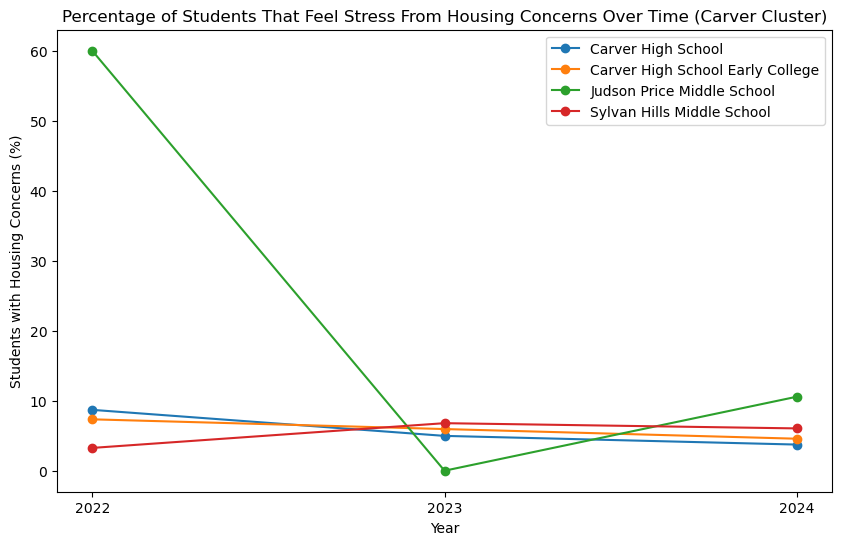

In [3]:
plt.figure(figsize=(10, 6))
for school in housing_carver_tsa["school"].unique():
    school_data = housing_carver_tsa[housing_carver_tsa["school"] == school]
    plt.plot(school_data["year"], school_data["percent_housing_concern"], marker="o", label=school)
plt.title("Percentage of Students That Feel Stress From Housing Concerns Over Time (Carver Cluster)")
plt.xlabel("Year")
plt.ylabel("Students with Housing Concerns (%)")
plt.xticks(housing_carver_tsa["year"].unique())
plt.legend()
plt.show()